# Mask R-CNN — Training Pipeline & Results

**Architecture:** Mask R-CNN (ResNet50-FPN backbone)

| Section | Content |
|---|---|
| Section 1 | Quantitative results: Table 2 & Table 3 (embedded outputs) |
| Section 2 | Fold-wise Dice boxplot — Figure 4 |
| Section 3 | Prediction overlay grid — Figure 5 (Mask R-CNN column) |
| Section 4 | Training code (requires GPU) |

> **Manuscript reference:** Table 2 (Mask R-CNN), Table 3 (Mask R-CNN), Figure 4, Figure 5, Section 2.2.4

---
## Section 1: Quantitative Results

Results from the trained Mask R-CNN models evaluated on the held-out test sets.

Values below match **Table 2** (segmentation: Dice, IoU, Pixel Acc.) and **Table 3** (classification: Accuracy, Sensitivity, Specificity, F1) in the manuscript.

# Mask R-CNN Test Tables Fixed

Bu notebook Mask R-CNN icin test tablolari dogru patient-level ve slice-level CSV'lerden yeniden uretir.

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score

PRED_ROOT = Path("models2/maskrcnn/pred2")
N_FOLDS = 5


In [2]:
seg_rows = []
cls_rows = []

for fold in range(1, N_FOLDS + 1):
    fold_dir = PRED_ROOT / f"fold_{fold}"
    seg_df = pd.read_csv(fold_dir / "kesit_duzeyi_sonuclar.csv")
    cls_df = pd.read_csv(fold_dir / "patient_level_results.csv")

    seg_rows.append({
        "Fold": f"Fold {fold}",
        "Dice Score": round(seg_df["seg_dice"].mean() * 100, 2),
        "IoU": round(seg_df["seg_jaccard"].mean() * 100, 2),
        "Pixel Acc.": round(seg_df["seg_piksel_dogruluk"].mean() * 100, 2),
    })

    y_true = cls_df["y_true_bin"].astype(int)
    y_pred = cls_df["pred_mean"].astype(int)
    y_score = cls_df["p_mean"].astype(float)
    cls_rows.append({
        "Fold": f"Fold {fold}",
        "Accuracy": round((y_true == y_pred).mean() * 100, 2),
        "F1 Score": round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
        "ROC-AUC": round(roc_auc_score(y_true, y_score) * 100, 2),
        "PR-AUC": round(average_precision_score(y_true, y_score) * 100, 2),
    })

seg_table = pd.DataFrame(seg_rows)
cls_table = pd.DataFrame(cls_rows)

seg_numeric = seg_table[["Dice Score", "IoU", "Pixel Acc."]]
cls_numeric = cls_table[["Accuracy", "F1 Score", "ROC-AUC", "PR-AUC"]]

seg_table.loc[len(seg_table)] = {
    "Fold": "Mean±Std",
    "Dice Score": f"{seg_numeric['Dice Score'].mean():.2f} ± {seg_numeric['Dice Score'].std(ddof=1):.2f}",
    "IoU": f"{seg_numeric['IoU'].mean():.2f} ± {seg_numeric['IoU'].std(ddof=1):.2f}",
    "Pixel Acc.": f"{seg_numeric['Pixel Acc.'].mean():.2f} ± {seg_numeric['Pixel Acc.'].std(ddof=1):.2f}",
}

cls_table.loc[len(cls_table)] = {
    "Fold": "Mean±Std",
    "Accuracy": f"{cls_numeric['Accuracy'].mean():.2f} ± {cls_numeric['Accuracy'].std(ddof=1):.2f}",
    "F1 Score": f"{cls_numeric['F1 Score'].mean():.2f} ± {cls_numeric['F1 Score'].std(ddof=1):.2f}",
    "ROC-AUC": f"{cls_numeric['ROC-AUC'].mean():.2f} ± {cls_numeric['ROC-AUC'].std(ddof=1):.2f}",
    "PR-AUC": f"{cls_numeric['PR-AUC'].mean():.2f} ± {cls_numeric['PR-AUC'].std(ddof=1):.2f}",
}

seg_out = PRED_ROOT / "test_segmentation_table_fixed.csv"
cls_out = PRED_ROOT / "test_classification_table_fixed.csv"
seg_table.to_csv(seg_out, index=False)
cls_table.to_csv(cls_out, index=False)

print("Kaydedildi:", seg_out)
print("Kaydedildi:", cls_out)


Kaydedildi: models2/maskrcnn/pred2/test_segmentation_table_fixed.csv
Kaydedildi: models2/maskrcnn/pred2/test_classification_table_fixed.csv


In [3]:
print("Tablo 4 - Test segmentasyon")
display(seg_table)

print("Tablo 5 - Test hasta duzeyi siniflandirma")
display(cls_table)


Tablo 4 - Test segmentasyon


,Fold,Dice Score,IoU,Pixel Acc.
0,Fold 1,76.23,65.96,99.23
1,Fold 2,71.67,61.45,98.74
2,Fold 3,78.47,67.53,99.18
3,Fold 4,73.4,63.69,99.26
4,Fold 5,76.8,66.4,98.43
5,Mean±Std,75.31 ± 2.74,65.01 ± 2.43,98.97 ± 0.37


Tablo 5 - Test hasta duzeyi siniflandirma


,Fold,Accuracy,F1 Score,ROC-AUC,PR-AUC
0,Fold 1,84.62,83.33,82.5,65.95
1,Fold 2,92.31,92.31,97.62,98.21
2,Fold 3,76.92,76.92,88.1,85.56
3,Fold 4,100.0,100.0,100.0,100.0
4,Fold 5,84.62,80.0,95.0,92.67
5,Mean±Std,87.69 ± 8.77,86.51 ± 9.49,92.64 ± 7.21,88.48 ± 13.79


---
## Section 2: Fold-wise Dice Score Boxplot

Distribution of per-fold Dice scores — **Figure 4** in the manuscript.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

PRED_ROOT = Path("models2/maskrcnn/pred2")
N_BOOT = 2000
RNG_SEED = 42


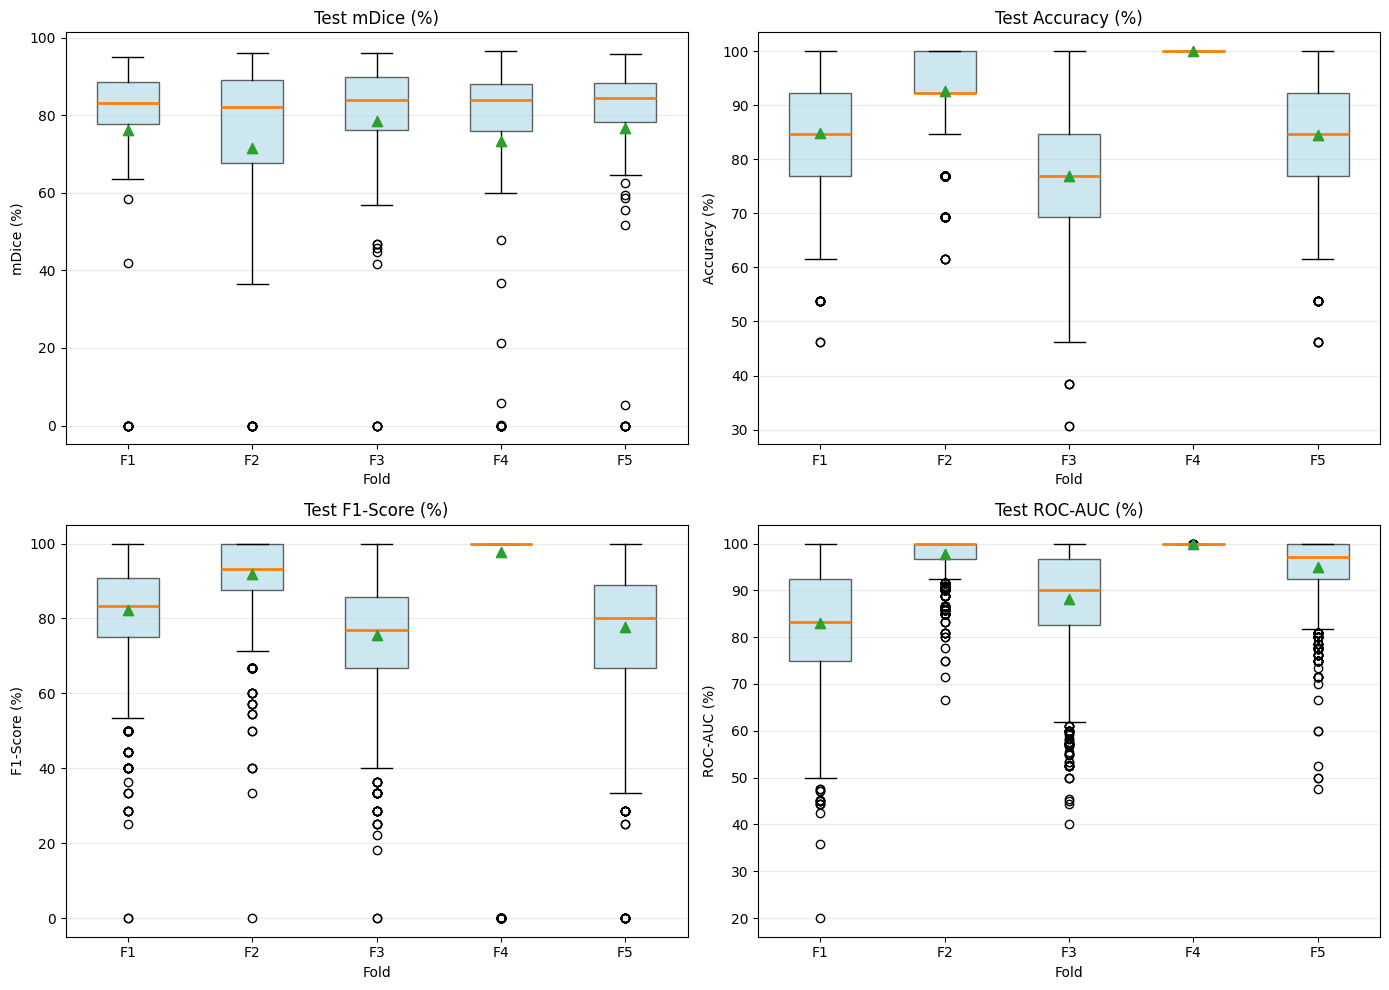

Kaydedildi: models2/maskrcnn/pred2/per_fold_boxplots_fixed.png


In [2]:
def pick_col(df, *candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Missing columns: {candidates}")

def read_csv_by_names(folder, names):
    for name in names:
        path = folder / name
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(f"No matching CSV under {folder}: {names}")

def bootstrap_patient_metrics(df, truth_col, pred_col, score_col, n_boot=N_BOOT, seed=RNG_SEED):
    truth = pd.to_numeric(df[truth_col], errors="coerce").to_numpy(dtype=float)
    pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy(dtype=float)
    score = pd.to_numeric(df[score_col], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(truth) & np.isfinite(pred) & np.isfinite(score)
    y_true = truth[mask].astype(int)
    y_pred = pred[mask].astype(int)
    y_score = score[mask].astype(float)
    rng = np.random.default_rng(seed)
    accs, f1s, rocs = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        yt = y_true[idx]
        yp = y_pred[idx]
        ys = y_score[idx]
        accs.append(accuracy_score(yt, yp) * 100.0)
        f1s.append(f1_score(yt, yp, zero_division=0) * 100.0)
        if np.unique(yt).size == 2:
            rocs.append(roc_auc_score(yt, ys) * 100.0)
    return np.asarray(accs), np.asarray(f1s), np.asarray(rocs)

def styled_boxplot(ax, data_by_fold, title, ylabel, fold_labels):
    bp = ax.boxplot(data_by_fold, tick_labels=fold_labels, patch_artist=True, showfliers=True, widths=0.5)
    for patch in bp["boxes"]:
        patch.set_facecolor("#add8e6")
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
    for med in bp["medians"]:
        med.set_color("#ff7f0e")
        med.set_linewidth(2)
    for item in bp["whiskers"] + bp["caps"]:
        item.set_color("black")
    means = [float(np.mean(x)) if len(x) else np.nan for x in data_by_fold]
    ax.scatter(np.arange(1, len(means) + 1), means, marker="^", s=55, color="#2ca02c", zorder=3)
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

fold_labels, dice_data, acc_data, f1_data, roc_data = [], [], [], [], []

for fold in range(1, 6):
    fold_dir = PRED_ROOT / f"fold_{fold}"
    if not fold_dir.exists():
        continue
    slice_df = read_csv_by_names(fold_dir, ["slice_level_results.csv", "kesit_duzeyi_sonuclar.csv"])
    patient_df = read_csv_by_names(fold_dir, ["patient_level_results.csv", "hasta_duzeyi_sonuclar.csv"])
    dice_col = pick_col(slice_df, "seg_dice")
    truth_col = pick_col(patient_df, "y_true_bin", "gt_sinif_bin")
    pred_col = pick_col(patient_df, "pred_mean", "tahmin_ortalama")
    score_col = pick_col(patient_df, "p_mean", "p_ortalama")
    dice = pd.to_numeric(slice_df[dice_col], errors="coerce").dropna().to_numpy(dtype=float) * 100.0
    accs, f1s, rocs = bootstrap_patient_metrics(patient_df, truth_col, pred_col, score_col)
    fold_labels.append(f"F{fold}")
    dice_data.append(dice)
    acc_data.append(accs)
    f1_data.append(f1s)
    roc_data.append(rocs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
styled_boxplot(axes[0, 0], dice_data, "Test mDice (%)", "mDice (%)", fold_labels)
styled_boxplot(axes[0, 1], acc_data, "Test Accuracy (%)", "Accuracy (%)", fold_labels)
styled_boxplot(axes[1, 0], f1_data, "Test F1-Score (%)", "F1-Score (%)", fold_labels)
styled_boxplot(axes[1, 1], roc_data, "Test ROC-AUC (%)", "ROC-AUC (%)", fold_labels)
plt.tight_layout()
out_png = PRED_ROOT / "per_fold_boxplots_fixed.png"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.show()
print("Kaydedildi:", out_png)


---
## Section 3: Prediction Overlay Grid

Ground-truth contours (white) vs. predicted contours (red) — **Figure 5** (Mask R-CNN column) in the manuscript.

In [24]:
overlay_paths = {}
print("Generating overlays...")
for img_name in IMAGES_TO_PROCESS:
    res = create_hollow_overlay(img_name)
    if res:
        overlay_paths[img_name] = res
        print(f"Created: {res}")

Generating overlays...
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_005_R_P_001.png
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_006_R_P_003.png


Grid image successfully saved: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/mrcnn_2x2_comparison.png


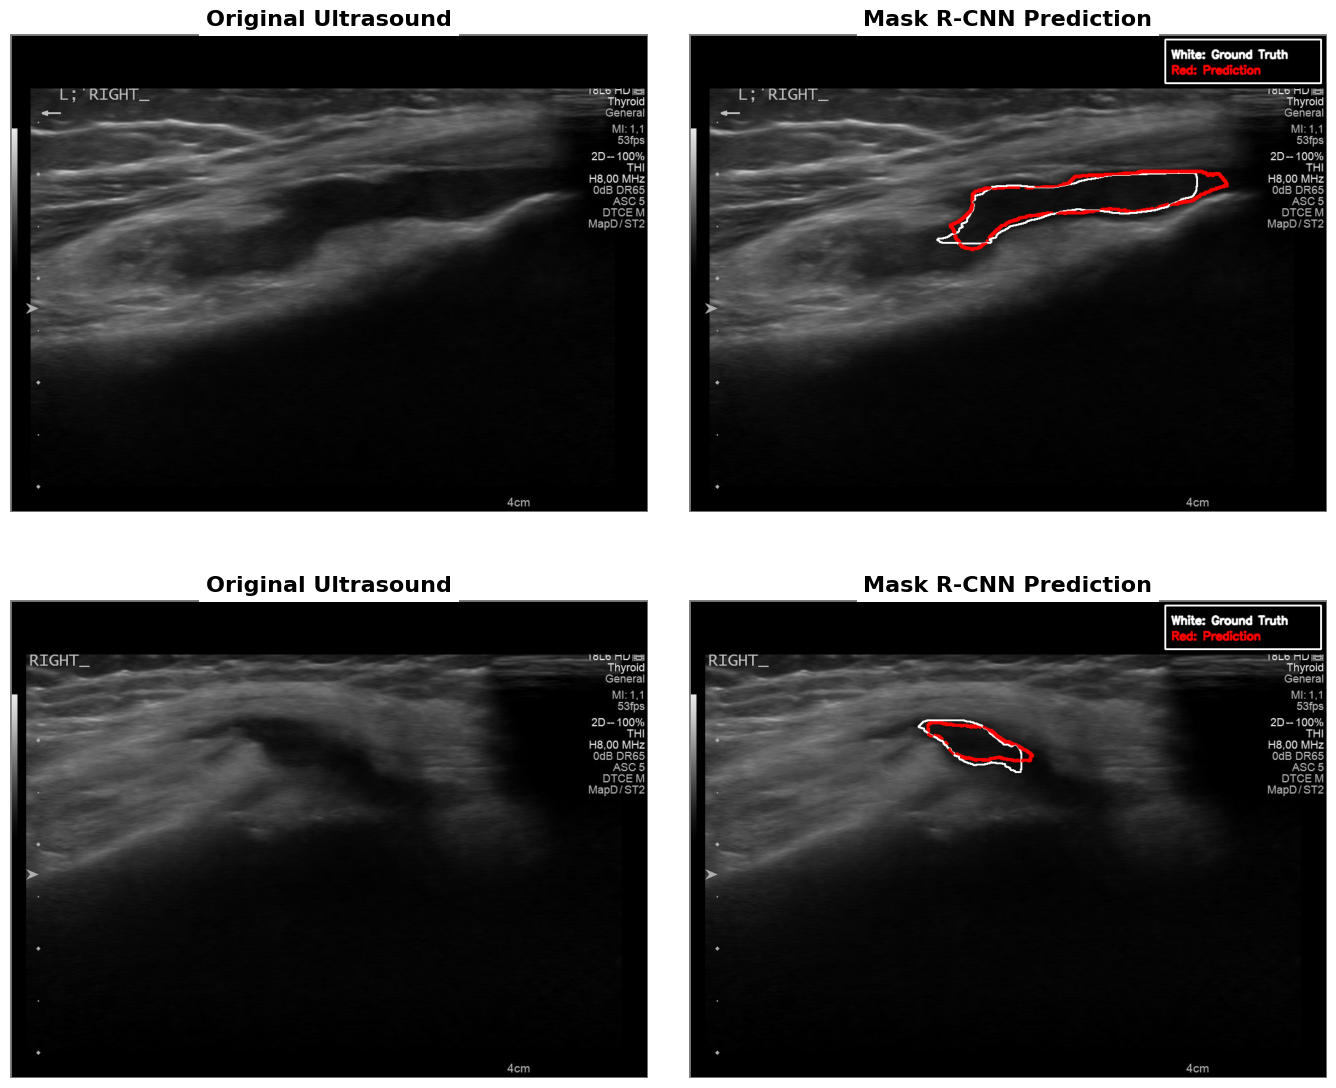

In [25]:
grid_out_path = os.path.join(OUT_DIR, 'mrcnn_2x2_comparison.png')
# Use a non-transparent figure to avoid black text on black background when pasting to slides
fig, axes = plt.subplots(len(IMAGES_TO_PROCESS), 2, figsize=(14, 6 * len(IMAGES_TO_PROCESS)))
fig.patch.set_facecolor('white') # Solid white background

for i, img_name in enumerate(IMAGES_TO_PROCESS):
    base_path = os.path.join(BASE_DIR, img_name)
    overlay_path = overlay_paths.get(img_name)
    
    # Read Base Image
    if os.path.exists(base_path):
        base_img = cv2.imread(base_path)
        base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
    else:
        base_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Read Overlay Image
    if overlay_path and os.path.exists(overlay_path):
        overlay_img = cv2.imread(overlay_path)
        overlay_img = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
    else:
        overlay_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Column 1 (Left): Original Image
    ax_base = axes[i, 0] if len(IMAGES_TO_PROCESS) > 1 else axes[0]
    ax_base.imshow(base_img)
    # Add white background to titles so they show up perfectly when copying
    ax_base.set_title('Original Ultrasound', fontsize=16, fontweight='bold', color='black', 
                      bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_base.axis('off')
    
    rect_base = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_base.transAxes)
    ax_base.add_patch(rect_base)
    
    # Column 2 (Right): Hollow Mask Overlay
    ax_ov = axes[i, 1] if len(IMAGES_TO_PROCESS) > 1 else axes[1]
    ax_ov.imshow(overlay_img)
    # Explanatory title matching user request
    ax_ov.set_title('Mask R-CNN Prediction', fontsize=16, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_ov.axis('off')
    
    rect_ov = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_ov.transAxes)
    ax_ov.add_patch(rect_ov)

plt.tight_layout(pad=3.0)
# DO NOT use transparent=True here, so it pastes safely onto dark slides without vanishing text
plt.savefig(grid_out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Grid image successfully saved: {grid_out_path}")
plt.show() # Display inline in Jupyter

---
## Section 4: Training Code

> **Note:** Requires GPU and the original dataset. The outputs in Sections 1–3 were produced by running this training pipeline.

In [1]:
import torch
torch.cuda.empty_cache()

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
import cv2
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms as T
import torchvision

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from sklearn.metrics import roc_curve, auc, confusion_matrix, f1_score

from sklearn.model_selection import KFold
from pycocotools.coco import COCO
import pycocotools.mask as mask_util

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd





In [4]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, json_path, transforms=None):
        """
        root_dir: path to the directory with images
        json_path: path to the COCO-format .json (combined for train+val)
        transforms: optional torchvision transforms
        """
        self.root_dir = root_dir
        self.coco = COCO(json_path)
        self.image_ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.root_dir, image_info["file_name"])

        # 1) Read image in OpenCV BGR, convert to RGB
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2) Apply transforms
        if self.transforms is not None:
            image = self.transforms(image)

        # 3) Annotations
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        masks = []

        for ann in annotations:
            x_min, y_min, w, h = ann["bbox"]
            x_max = x_min + w
            y_max = y_min + h
            boxes.append([x_min, y_min, x_max, y_max])
            labels.append(ann["category_id"])

            # Convert segmentation to binary mask
            seg = ann['segmentation']
            rle = mask_util.frPyObjects(seg, image_info['height'], image_info['width'])
            m = mask_util.decode(rle)
            if len(m.shape) == 3:  # multiple polygons
                m = np.any(m, axis=2)
            masks.append(m.astype(bool))

        # 4) Convert to tensors
        boxes  = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        if len(masks) > 0:
            masks_t = [torch.from_numpy(x).bool() for x in masks]
            masks = torch.stack(masks_t, dim=0)
        else:
            # if no annotations
            masks = torch.zeros((0, image.shape[-2], image.shape[-1]), dtype=torch.bool)

        targets = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([image_id]),
            "file_name": image_info["file_name"]
        }
        return image, targets

    def __len__(self):
        return len(self.image_ids)

def collate_fn(batch):
    return tuple(zip(*batch))


In [5]:
def get_maskrcnn_model(num_classes):

    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

    # Replace Box Predictor
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # Replace Mask Predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_channels=in_features_mask,
        dim_reduced=hidden_layer,
        num_classes=num_classes
    )
    return model

In [6]:

def compute_classwise_metrics_from_cm(cm, class_names=None):

    num_classes = cm.shape[0]
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(num_classes)]
    metrics_dict = {}
    total = cm.sum()
    for c in range(num_classes):
        TP = cm[c,c]
        FN = cm[c,:].sum() - TP
        FP = cm[:,c].sum() - TP
        TN = total - (TP + FP + FN)

        accuracy    = (TP+TN) / (TP+TN+FP+FN) if (TP+TN+FP+FN) > 0 else 0
        precision   = TP / (TP+FP) if (TP+FP) > 0 else 0
        recall      = TP / (TP+FN) if (TP+FN) > 0 else 0
        specificity = TN / (TN+FP) if (TN+FP) > 0 else 0
        f1          = (2 * precision * recall) / (precision+recall) if (precision+recall) > 0 else 0

        metrics_dict[class_names[c]] = {
            "Accuracy":    accuracy,
            "Precision":   precision,
            "Recall":      recall,
            "Specificity": specificity,
            "F1":          f1
        }
    return metrics_dict


def plot_confusion_matrix(cm, class_names=None, title="Confusion Matrix"):

    if class_names is None:
        class_names = [f"Class_{i}" for i in range(cm.shape[0])]
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    plt.figure(figsize=(6, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()




In [7]:

def calculate_dice_score(mask1, mask2):

    intersection = np.logical_and(mask1, mask2).sum()
    sum_masks = mask1.sum() + mask2.sum()
    if sum_masks == 0:
        return 0.0
    return (2.0 * intersection) / sum_masks


def calculate_jaccard_index(mask1, mask2):

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection / union


def plot_roc_curve(y_true, y_scores, title='ROC Curve'):

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,7))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.4)
    plt.show()

    print(f"AUC: {roc_auc:.3f}")


In [8]:

def overlay_segmentation(image, gt_mask, pred_mask, text_color=(255, 255, 255)):

    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
        if image.ndim == 4:  # [B,C,H,W] durumu
            image = image[0]
        image = np.transpose(image, (1,2,0))  # C,H,W -> H,W,C
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)

    out_img = image.copy()
    if out_img.ndim == 2:
        out_img = cv2.cvtColor(out_img, cv2.COLOR_GRAY2BGR)

    gt_u8   = gt_mask.astype(np.uint8)
    pred_u8 = pred_mask.astype(np.uint8)

    contours_gt,   _ = cv2.findContours(gt_u8,   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pred, _ = cv2.findContours(pred_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Çizim
    cv2.drawContours(out_img, contours_gt,   -1, (0, 0, 255),   2)  # GT kırmızı çizgi
    cv2.drawContours(out_img, contours_pred, -1, (255, 0, 0),   2)  # Prediction mavi çizgi

    # Sağ üst köşeye açıklama ekle
    legend = "Ground truth (Red), Prediction (Blue)"
    h, w = out_img.shape[:2]
    text_size = cv2.getTextSize(legend, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = w - (text_size[0] + 10)
    text_y = 30
    cv2.putText(
        out_img, legend, (text_x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, text_color, 2, cv2.LINE_AA
    )

    return out_img


In [9]:
import torch

def mask_nms(masks, scores, iou_threshold=0.5, binarize_threshold=0.5):
    if masks is None or scores is None:
        return torch.empty((0,), dtype=torch.long)
    if masks.numel() == 0 or scores.numel() == 0:
        return torch.empty((0,), dtype=torch.long)

    if masks.ndim == 4:
        masks = masks.squeeze(1)
    if masks.ndim != 3:
        raise ValueError(f"masks shape beklenmiyor: {tuple(masks.shape)}")

    device = masks.device
    masks_bin = masks > float(binarize_threshold)

    order = torch.argsort(scores, descending=True)
    keep = []

    while order.numel() > 0:
        i = order[0]
        keep.append(i)

        if order.numel() == 1:
            break

        rest = order[1:]

        mi = masks_bin[i].reshape(1, -1)
        mr = masks_bin[rest].reshape(rest.numel(), -1)

        inter = torch.logical_and(mr, mi).sum(dim=1).to(torch.float32)
        union = torch.logical_or(mr, mi).sum(dim=1).to(torch.float32)
        iou = inter / (union + 1e-6)

        rest = rest[iou <= float(iou_threshold)]
        order = rest

    return torch.stack(keep).to(device=device, dtype=torch.long)


In [10]:
import os
from pathlib import Path
import numpy as np
import torch
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

def evaluate_on_test_set(best_model_path, test_loader, device, fold_index, num_classes, output_root):
    model_test = get_maskrcnn_model(num_classes=num_classes).to(device)
    model_test.load_state_dict(torch.load(best_model_path, map_location=device))
    model_test.eval()

    y_true, y_pred, y_scores = [], [], []
    dice_scores = []
    jaccard_scores = []
    segmentation_accuracies = []

    patient_correct, patient_total = {}, {}

    output_base_dir = Path(output_root) / f"fold_{fold_index}"
    output_base_dir.mkdir(parents=True, exist_ok=True)

    def extract_patient_id(file_name):
        stem = Path(file_name).stem
        parts = stem.split("_")
        if len(parts) >= 5 and parts[0].lower() == "image":
            pid_num = parts[1]
            flag = parts[3]
            if flag == "P":
                return f"Arthritis Patient ID :{pid_num}"
            if flag == "C":
                return f"Control Patient ID :{pid_num}"
            return f"Unknown Category ID :{pid_num}"
        if len(parts) >= 2:
            pid_num = parts[1]
            if "P" in parts:
                return f"Arthritis Patient ID :{pid_num}"
            if "C" in parts:
                return f"Control Patient ID :{pid_num}"
            return f"Unknown Category ID :{pid_num}"
        return f"Unknown Category ID :{stem}"

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Test Inference (Fold {fold_index})"):
            image = images[0].to(device)
            target = targets[0]

            output = model_test([image])[0]

            if "masks" in output and "scores" in output and output["masks"].shape[0] > 0:
                masks_t = output["masks"].squeeze(1)
                scores_t = output["scores"]
                keep = mask_nms(masks_t, scores_t, iou_threshold=0.5)
                output["masks"] = masks_t[keep].unsqueeze(1)
                output["scores"] = scores_t[keep]
                output["labels"] = output["labels"][keep]

            file_name = target["file_name"]
            patient_id = extract_patient_id(file_name)

            if patient_id not in patient_total:
                patient_total[patient_id] = 0
                patient_correct[patient_id] = 0
            patient_total[patient_id] += 1

            gt_masks = target["masks"].cpu().numpy()
            if gt_masks.shape[0] > 0:
                gt_mask = np.any(gt_masks, axis=0).astype(np.uint8)
            else:
                gt_mask = np.zeros((image.shape[1], image.shape[2]), dtype=np.uint8)

            pred_labels_all = output["labels"].detach().cpu().numpy() if "labels" in output else np.array([])
            pred_scores_all = output["scores"].detach().cpu().numpy() if "scores" in output else np.array([])
            pred_masks_all = output["masks"].detach().cpu().numpy()[:, 0, :, :] if "masks" in output else np.zeros((0, *gt_mask.shape), dtype=np.float32)

            seg_keep = pred_scores_all >= 0.5
            pred_masks_seg = pred_masks_all[seg_keep]
            pred_scores_seg = pred_scores_all[seg_keep]

            if pred_masks_seg.shape[0] > 0:
                idx_best_seg = int(np.argmax(pred_scores_seg))
                pred_mask = (pred_masks_seg[idx_best_seg] > 0.5).astype(np.uint8)
            else:
                pred_mask = np.zeros_like(gt_mask)

            dice = calculate_dice_score(gt_mask, pred_mask)
            jaccard = calculate_jaccard_index(gt_mask, pred_mask)
            dice_scores.append(float(dice))
            jaccard_scores.append(float(jaccard))

            correct_pixels = np.sum(gt_mask == pred_mask)
            total_pixels = gt_mask.size
            seg_accuracy = float(correct_pixels / total_pixels)
            segmentation_accuracies.append(seg_accuracy)

            gt_class = int(target["labels"][0].item())

            if pred_scores_all.shape[0] > 0:
                idx_best_cls = int(np.argmax(pred_scores_all))
                pred_class = int(pred_labels_all[idx_best_cls])
                best_score = float(pred_scores_all[idx_best_cls])
            else:
                pred_class = 2
                best_score = 0.0

            if gt_class != -1:
                if gt_class == pred_class:
                    patient_correct[patient_id] += 1

                y_true.append(gt_class)
                y_pred.append(pred_class)
                y_scores.append(best_score)

            overlay_img = overlay_segmentation(image, gt_mask, pred_mask)
            save_file = output_base_dir / f"{file_name}_overlay.png"
            cv2.imwrite(str(save_file), cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR))

    patient_accuracies = {p: patient_correct[p] / patient_total[p] for p in patient_total}
    classification_accuracy = float(np.mean(list(patient_accuracies.values()))) if patient_accuracies else 0.0

    mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0
    mean_jaccard = float(np.mean(jaccard_scores)) if jaccard_scores else 0.0
    mean_segmentation_acc = float(np.mean(segmentation_accuracies)) if segmentation_accuracies else 0.0

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    y_scores = np.array(y_scores, dtype=float)

    cm = confusion_matrix(y_true, y_pred, labels=[2, 1])
    class_names = ["Control", "Arthritis"]
    plot_confusion_matrix(cm, class_names=class_names, title=f"Confusion Matrix (Fold {fold_index})")

    classwise_metrics = compute_classwise_metrics_from_cm(cm, class_names=class_names)

    roc_y_true = np.array([1 if x == 1 else 0 for x in y_true], dtype=int)
    if len(np.unique(roc_y_true)) == 2:
        fpr, tpr, _ = roc_curve(roc_y_true, y_scores)
        roc_auc = float(auc(fpr, tpr))
    else:
        roc_auc = 0.0
        fpr, tpr = [0, 1], [0, 1]

    txt_file = output_base_dir / f"results_fold_{fold_index}.txt"
    with open(txt_file, "w", encoding="utf-8") as f:
        f.write("Patient-wise Classification Accuracy:\n")
        for pid in sorted(patient_accuracies.keys()):
            f.write(f"  {pid} => {patient_accuracies[pid]:.3f}\n")

        f.write(f"\n--- Segmentation Metrics ---\n")
        f.write(f"Mean Dice: {mean_dice:.3f}\n")
        f.write(f"Mean Jaccard: {mean_jaccard:.3f}\n")
        f.write(f"Mean Segmentation Accuracy: {mean_segmentation_acc:.3f}\n")

        f.write(f"\n--- Classification Metrics ---\n")
        f.write(f"Patient-wise Mean Accuracy: {classification_accuracy:.3f}\n")
        f.write(f"ROC AUC: {roc_auc:.3f}\n")

        f.write(f"\n--- Class-wise Metrics ---\n")
        for class_name, metrics in classwise_metrics.items():
            f.write(f"{class_name}:\n")
            for metric_name, value in metrics.items():
                f.write(f"  {metric_name}: {value:.3f}\n")

    sorted_patients = sorted(patient_accuracies.keys())
    sorted_accs = [patient_accuracies[x] for x in sorted_patients]

    plt.figure(figsize=(12, 5))
    plt.bar(sorted_patients, sorted_accs)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Hasta ID")
    plt.ylabel("Doğruluk")
    plt.title(f"Hasta Bazlı Sınıflandırma Doğruluğu (Fold {fold_index})")
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(str(output_base_dir / f"accuracy_plot_fold_{fold_index}.png"))
    plt.close()

    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Fold {fold_index})')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.4)
    plt.savefig(str(output_base_dir / f"roc_curve_fold_{fold_index}.png"))
    plt.close()

    print(f"\n--- Fold {fold_index} Results ---")
    print(f"Mean Dice: {mean_dice:.3f}")
    print(f"Mean Jaccard: {mean_jaccard:.3f}")
    print(f"Mean Segmentation Accuracy: {mean_segmentation_acc:.3f}")
    print(f"Classification Accuracy (patient-wise avg): {classification_accuracy:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    print("Outputs:", str(output_base_dir.resolve()))

    return mean_dice, mean_jaccard, mean_segmentation_acc, classification_accuracy, roc_auc


In [11]:
def freeze_bn_layers(model):
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()
    return model

In [13]:
import json
from pathlib import Path
import numpy as np
import cv2

def find_base_folds():
    cands = [
        Path("/home/zera/Desktop/data_fold/folds/folds"),
        Path("folds"),
    ]
    for c in cands:
        if c.exists():
            return c
    raise FileNotFoundError("folds klasörü bulunamadı")

def img_to_mask_path(img_path: Path, roi_dir: Path) -> Path:
    name = img_path.name
    if name.startswith("image_"):
        mname = "mask_" + name[len("image_"):]
    else:
        mname = "mask_" + name
    p = roi_dir / mname
    if p.exists():
        return p
    p2 = roi_dir / (Path(mname).stem + ".png")
    if p2.exists():
        return p2
    p3 = roi_dir / (Path(mname).stem + ".jpg")
    if p3.exists():
        return p3
    p4 = roi_dir / (Path(mname).stem + ".jpeg")
    if p4.exists():
        return p4
    raise FileNotFoundError(str(p.resolve()))

def category_id_from_name(fname: str):
    s = fname
    if "_P_" in s:
        return 1
    if "_C_" in s:
        return 2
    return None

def mask_to_segmentation(mask_u8):
    cnts, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segs = []
    for c in cnts:
        if c.shape[0] < 3:
            continue
        c = c.astype(np.float32).squeeze(1)
        if c.shape[0] < 3:
            continue
        seg = c.flatten().tolist()
        if len(seg) >= 6:
            segs.append(seg)
    return segs

def build_coco(images_dir: Path, roi_dir: Path, out_json: Path):
    exts = {".png", ".jpg", ".jpeg"}
    imgs = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in exts])
    if len(imgs) == 0:
        raise FileNotFoundError(str(images_dir.resolve()))

    coco = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "arthrit", "supercategory": "knee"},
            {"id": 2, "name": "control", "supercategory": "knee"},
        ],
    }

    ann_id = 1
    img_id = 1

    for img_path in imgs:
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        h, w = img.shape[:2]

        coco["images"].append({
            "id": img_id,
            "file_name": img_path.name,
            "width": int(w),
            "height": int(h),
        })

        cat_id = category_id_from_name(img_path.name)
        if cat_id is None:
            img_id += 1
            continue

        try:
            mask_path = img_to_mask_path(img_path, roi_dir)
        except FileNotFoundError:
            img_id += 1
            continue

        m = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if m is None:
            img_id += 1
            continue

        if m.shape[0] != h or m.shape[1] != w:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

        m = (m > 0).astype(np.uint8) * 255
        area = int((m > 0).sum())
        if area == 0:
            img_id += 1
            continue

        ys, xs = np.where(m > 0)
        x_min = int(xs.min())
        x_max = int(xs.max())
        y_min = int(ys.min())
        y_max = int(ys.max())
        bbox_w = int(x_max - x_min + 1)
        bbox_h = int(y_max - y_min + 1)

        segs = mask_to_segmentation(m)
        if len(segs) == 0:
            img_id += 1
            continue

        coco["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": int(cat_id),
            "segmentation": segs,
            "area": float(area),
            "bbox": [float(x_min), float(y_min), float(bbox_w), float(bbox_h)],
            "iscrowd": 0,
        })
        ann_id += 1
        img_id += 1

    out_json.parent.mkdir(parents=True, exist_ok=True)
    out_json.write_text(json.dumps(coco, ensure_ascii=False), encoding="utf-8")
    return out_json

BASE_FOLDS = find_base_folds()

for k in range(1, 6):
    fold_dir = BASE_FOLDS / f"FOLD_{k}"

    tv_img = fold_dir / "train_val" / "darkened"
    tv_roi = fold_dir / "train_val" / "ROI"
    te_img = fold_dir / "test" / "darkened"
    te_roi = fold_dir / "test" / "ROI"

    if not tv_img.exists() or not tv_roi.exists():
        raise FileNotFoundError(str((fold_dir / "train_val").resolve()))
    if not te_img.exists() or not te_roi.exists():
        raise FileNotFoundError(str((fold_dir / "test").resolve()))

    tv_json = fold_dir / "train_val" / "train_val_coco.json"
    te_json = fold_dir / "test" / "test_coco.json"

    build_coco(tv_img, tv_roi, tv_json)
    build_coco(te_img, te_roi, te_json)

print("OK")
print(str(BASE_FOLDS.resolve()))


OK
/home/zera/Desktop/data_fold/folds/folds


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


...

LR: 5e-05


LR: 5e-05


LR: 5e-05


LR: 5e-05


Test Inference (Fold 1): 100%|██████████| 130/130 [00:05<00:00, 22.97it/s]


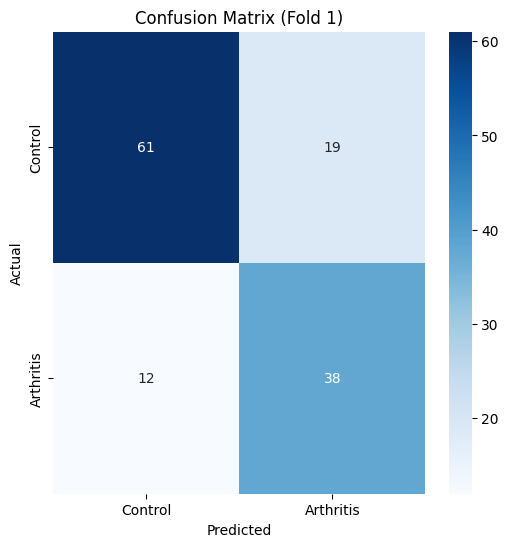

LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


...

LR: 5e-05


LR: 5e-05


LR: 5e-05


LR: 5e-05


Test Inference (Fold 2): 100%|██████████| 130/130 [00:05<00:00, 24.07it/s]


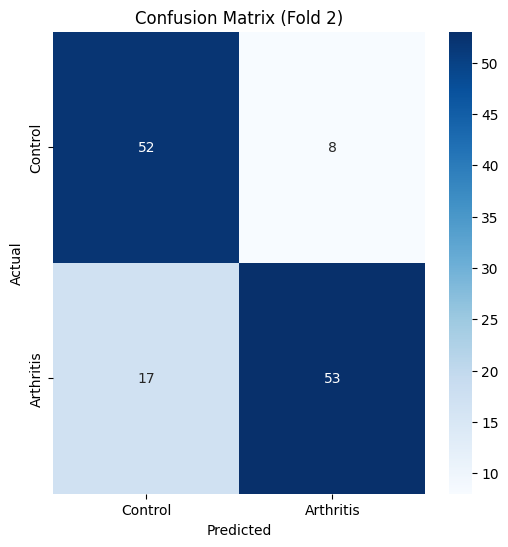

LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


...

LR: 5e-05


LR: 5e-05


LR: 5e-05


LR: 5e-05


Test Inference (Fold 3): 100%|██████████| 131/131 [00:05<00:00, 23.62it/s]


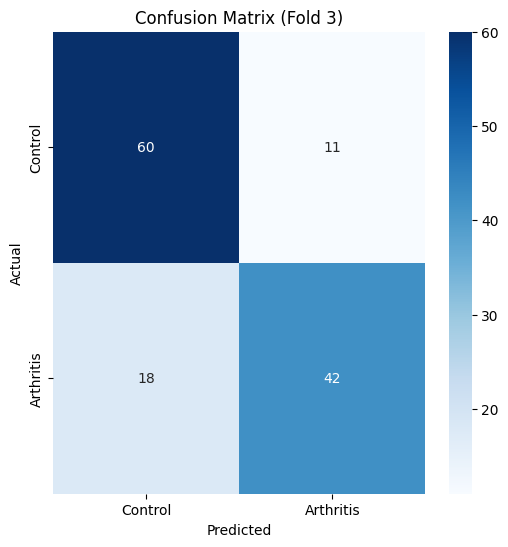

LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


...

LR: 5e-05


LR: 5e-05


LR: 5e-05


LR: 5e-05


Test Inference (Fold 4): 100%|██████████| 131/131 [00:05<00:00, 24.03it/s]


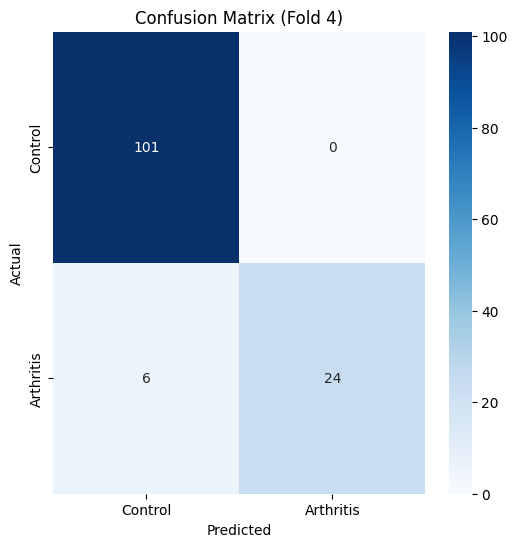

LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


LR: 0.0005


...

LR: 5e-05


LR: 5e-05


LR: 5e-05


LR: 5e-05


Test Inference (Fold 5): 100%|██████████| 133/133 [00:05<00:00, 23.49it/s]


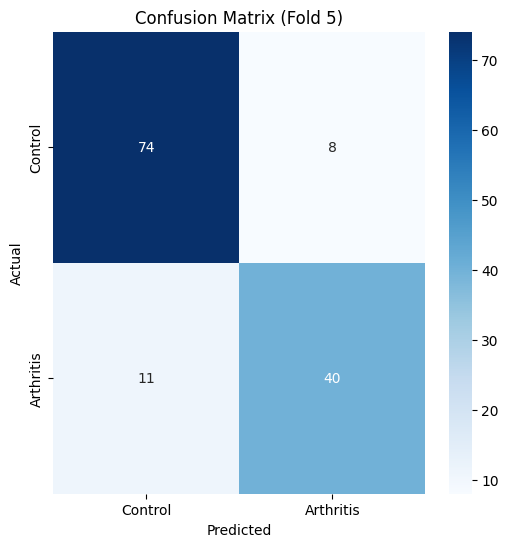

[{'fold_index': 1, 'train_pids': [np.str_('011'), np.str_('006'), np.str_('009'), np.str_('022'), np.str_('024'), np.str_('017'), np.str_('003'), np.str_('013'), np.str_('013'), np.str_('020'), np.str_('005'), np.str_('022'), np.str_('012'), np.str_('011'), np.str_('008')], 'val_pids': ['005', '018', '021', '016', '007'], 'train_samples': 509, 'val_samples': 173, 'best_val_loss': 0.3713477301326665, 'best_val_dice': 0.05133832380275486, 'best_threshold': 0.0, 'best_f1': 0.6377952755905512, 'best_model_path': '/home/zera/Desktop/tez_diz/TEZ_OLA_DIZ/models2/maskrcnn/new_best_model_fold1.pth', 'test_dice_score': 0.7623088617527812, 'test_jaccard_score': 0.6596422403023843, 'test_segmentation_accuracy': 0.9923397049138574, 'test_classification_accuracy': 0.7615384615384616, 'test_roc_auc': 0.5569999999999999}, {'fold_index': 2, 'train_pids': [np.str_('011'), np.str_('006'), np.str_('009'), np.str_('022'), np.str_('024'), np.str_('021'), np.str_('003'), np.str_('013'), np.str_('008'), np.st

In [ ]:
import os
import json
from pathlib import Path
import numpy as np
import cv2
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import torchvision.transforms as T
from collections import defaultdict
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

transform = T.Compose([T.ToPILImage(), T.ToTensor()])

BASE_FOLDS = Path("/home/zera/Desktop/tez_diz/TEZ_OLA_DIZ/folds")
MODELS_DIR = BASE_FOLDS.parent / "models2" / "maskrcnn"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR = MODELS_DIR / "pred2"
PRED_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 3
batch_size = 8
num_epochs = 100
base_lr = 5e-4
min_epochs = 50
max_early_stop = 10

n_folds = 5
required_train_c = 8
required_val_c = 3
required_train_p = 7
required_val_p = 2

def img_to_mask_path(img_path: Path, roi_dir: Path) -> Path:
    name = img_path.name
    if name.startswith("image_"):
        mname = "mask_" + name[len("image_"):]
    else:
        mname = "mask_" + name
    p = roi_dir / mname
    if p.exists():
        return p
    p2 = roi_dir / (Path(mname).stem + ".png")
    if p2.exists():
        return p2
    p3 = roi_dir / (Path(mname).stem + ".jpg")
    if p3.exists():
        return p3
    p4 = roi_dir / (Path(mname).stem + ".jpeg")
    if p4.exists():
        return p4
    raise FileNotFoundError(str(p.resolve()))

def category_id_from_name(fname: str):
    if "_P_" in fname:
        return 1
    if "_C_" in fname:
        return 2
    return None

def mask_to_segmentation(mask_u8):
    cnts, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segs = []
    for c in cnts:
        if c.shape[0] < 3:
            continue
        c = c.astype(np.float32).squeeze(1)
        if c.shape[0] < 3:
            continue
        seg = c.flatten().tolist()
        if len(seg) >= 6:
            segs.append(seg)
    return segs

def build_coco(images_dir: Path, roi_dir: Path, out_json: Path):
    exts = {".png", ".jpg", ".jpeg"}
    imgs = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in exts])
    if len(imgs) == 0:
        raise FileNotFoundError(str(images_dir.resolve()))

    coco = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "arthrit", "supercategory": "knee"},
            {"id": 2, "name": "control", "supercategory": "knee"},
        ],
    }

    ann_id = 1
    img_id = 1

    for img_path in imgs:
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            img_id += 1
            continue
        h, w = img.shape[:2]

        coco["images"].append({
            "id": img_id,
            "file_name": img_path.name,
            "width": int(w),
            "height": int(h),
        })

        cat_id = category_id_from_name(img_path.name)
        if cat_id is None:
            img_id += 1
            continue

        try:
            mask_path = img_to_mask_path(img_path, roi_dir)
        except FileNotFoundError:
            img_id += 1
            continue

        m = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if m is None:
            img_id += 1
            continue

        if m.shape[0] != h or m.shape[1] != w:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

        m = (m > 0).astype(np.uint8) * 255
        area = int((m > 0).sum())
        if area == 0:
            img_id += 1
            continue

        ys, xs = np.where(m > 0)
        x_min = int(xs.min())
        x_max = int(xs.max())
        y_min = int(ys.min())
        y_max = int(ys.max())
        bbox_w = int(x_max - x_min + 1)
        bbox_h = int(y_max - y_min + 1)

        segs = mask_to_segmentation(m)
        if len(segs) == 0:
            img_id += 1
            continue

        coco["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": int(cat_id),
            "segmentation": segs,
            "area": float(area),
            "bbox": [float(x_min), float(y_min), float(bbox_w), float(bbox_h)],
            "iscrowd": 0,
        })
        ann_id += 1
        img_id += 1

    out_json.parent.mkdir(parents=True, exist_ok=True)
    out_json.write_text(json.dumps(coco, ensure_ascii=False), encoding="utf-8")
    return out_json

def ensure_fold_coco(fold_dir: Path):
    trainval_dir = fold_dir / "train_val"
    test_dir = fold_dir / "test"

    tv_img = trainval_dir / "darkened"
    tv_roi = trainval_dir / "ROI"
    te_img = test_dir / "darkened"
    te_roi = test_dir / "ROI"

    if not tv_img.exists() or not tv_roi.exists():
        raise FileNotFoundError(str((fold_dir / "train_val").resolve()))
    if not te_img.exists() or not te_roi.exists():
        raise FileNotFoundError(str((fold_dir / "test").resolve()))

    tv_json = trainval_dir / "train_val_coco.json"
    te_json = test_dir / "test_coco.json"

    if not tv_json.exists():
        build_coco(tv_img, tv_roi, tv_json)
    if not te_json.exists():
        build_coco(te_img, te_roi, te_json)

    return tv_json, te_json

def dice_loss(pred, target, smooth=1):
    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) / (pred.sum() + target.sum() + smooth))

def evaluate_on_test_set(best_model_path, test_loader, device, fold_index, num_classes, output_root):
    model_test = get_maskrcnn_model(num_classes=num_classes).to(device)
    model_test.load_state_dict(torch.load(best_model_path, map_location=device))
    model_test.eval()

    y_true, y_pred, y_scores = [], [], []
    dice_scores = []
    jaccard_scores = []
    segmentation_accuracies = []

    patient_correct, patient_total = {}, {}

    output_base_dir = Path(output_root) / f"fold_{fold_index}"
    output_base_dir.mkdir(parents=True, exist_ok=True)

    def extract_patient_id(file_name):
        stem = Path(file_name).stem
        parts = stem.split("_")
        if len(parts) >= 5 and parts[0].lower() == "image":
            pid_num = parts[1]
            flag = parts[3]
            if flag == "P":
                return f"Arthritis Patient ID :{pid_num}"
            if flag == "C":
                return f"Control Patient ID :{pid_num}"
            return f"Unknown Category ID :{pid_num}"
        if len(parts) >= 2:
            pid_num = parts[1]
            if "P" in parts:
                return f"Arthritis Patient ID :{pid_num}"
            if "C" in parts:
                return f"Control Patient ID :{pid_num}"
            return f"Unknown Category ID :{pid_num}"
        return f"Unknown Category ID :{stem}"

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Test Inference (Fold {fold_index})"):
            image = images[0].to(device)
            target = targets[0]

            output = model_test([image])[0]

            if "masks" in output and "scores" in output and output["masks"].shape[0] > 0:
                keep = mask_nms(output["masks"].squeeze(1), output["scores"], iou_threshold=0.5)
                output["masks"] = output["masks"][keep]
                output["scores"] = output["scores"][keep]
                output["labels"] = output["labels"][keep]

            file_name = target["file_name"]
            patient_id = extract_patient_id(file_name)

            if patient_id not in patient_total:
                patient_total[patient_id] = 0
                patient_correct[patient_id] = 0
            patient_total[patient_id] += 1

            gt_masks = target["masks"].cpu().numpy()
            if gt_masks.shape[0] > 0:
                gt_mask = np.any(gt_masks, axis=0).astype(np.uint8)
            else:
                gt_mask = np.zeros((image.shape[1], image.shape[2]), dtype=np.uint8)

            pred_labels_all = output["labels"].detach().cpu().numpy() if "labels" in output else np.array([])
            pred_scores_all = output["scores"].detach().cpu().numpy() if "scores" in output else np.array([])
            pred_masks_all = output["masks"].detach().cpu().numpy()[:, 0, :, :] if "masks" in output else np.zeros((0, *gt_mask.shape), dtype=np.float32)

            seg_keep = pred_scores_all >= 0.5
            pred_masks_seg = pred_masks_all[seg_keep]
            pred_scores_seg = pred_scores_all[seg_keep]

            if pred_masks_seg.shape[0] > 0:
                idx_best_seg = int(np.argmax(pred_scores_seg))
                pred_mask = (pred_masks_seg[idx_best_seg] > 0.5).astype(np.uint8)
            else:
                pred_mask = np.zeros_like(gt_mask)

            dice = calculate_dice_score(gt_mask, pred_mask)
            jaccard = calculate_jaccard_index(gt_mask, pred_mask)
            dice_scores.append(float(dice))
            jaccard_scores.append(float(jaccard))

            correct_pixels = np.sum(gt_mask == pred_mask)
            total_pixels = gt_mask.size
            segmentation_accuracies.append(float(correct_pixels / total_pixels))

            gt_class = int(target["labels"][0].item())

            if pred_scores_all.shape[0] > 0:
                idx_best_cls = int(np.argmax(pred_scores_all))
                pred_class = int(pred_labels_all[idx_best_cls])
                best_score = float(pred_scores_all[idx_best_cls])
            else:
                pred_class = 2
                best_score = 0.0

            if gt_class != -1:
                if gt_class == pred_class:
                    patient_correct[patient_id] += 1
                y_true.append(gt_class)
                y_pred.append(pred_class)
                y_scores.append(best_score)

            overlay_img = overlay_segmentation(image, gt_mask, pred_mask)
            save_file = output_base_dir / f"{file_name}_overlay.png"
            cv2.imwrite(str(save_file), cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR))

    patient_accuracies = {p: patient_correct[p] / patient_total[p] for p in patient_total}
    classification_accuracy = float(np.mean(list(patient_accuracies.values()))) if patient_accuracies else 0.0

    mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0
    mean_jaccard = float(np.mean(jaccard_scores)) if jaccard_scores else 0.0
    mean_segmentation_acc = float(np.mean(segmentation_accuracies)) if segmentation_accuracies else 0.0

    y_true_arr = np.array(y_true, dtype=int)
    y_pred_arr = np.array(y_pred, dtype=int)
    y_scores_arr = np.array(y_scores, dtype=float)

    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[2, 1])
    class_names = ["Control", "Arthritis"]
    plot_confusion_matrix(cm, class_names=class_names, title=f"Confusion Matrix (Fold {fold_index})")
    classwise_metrics = compute_classwise_metrics_from_cm(cm, class_names=class_names)

    roc_y_true = np.array([1 if x == 1 else 0 for x in y_true_arr], dtype=int)
    if len(np.unique(roc_y_true)) == 2:
        fpr, tpr, _ = roc_curve(roc_y_true, y_scores_arr)
        roc_auc = float(auc(fpr, tpr))
    else:
        roc_auc = 0.0
        fpr, tpr = [0, 1], [0, 1]

    txt_file = output_base_dir / f"results_fold_{fold_index}.txt"
    with open(txt_file, "w", encoding="utf-8") as f:
        f.write("Patient-wise Classification Accuracy:\n")
        for pid in sorted(patient_accuracies.keys()):
            f.write(f"  {pid} => {patient_accuracies[pid]:.3f}\n")

        f.write("\n--- Segmentation Metrics ---\n")
        f.write(f"Mean Dice: {mean_dice:.3f}\n")
        f.write(f"Mean Jaccard: {mean_jaccard:.3f}\n")
        f.write(f"Mean Segmentation Accuracy: {mean_segmentation_acc:.3f}\n")

        f.write("\n--- Classification Metrics ---\n")
        f.write(f"Patient-wise Mean Accuracy: {classification_accuracy:.3f}\n")
        f.write(f"ROC AUC: {roc_auc:.3f}\n")

        f.write("\n--- Class-wise Metrics ---\n")
        for class_name, metrics in classwise_metrics.items():
            f.write(f"{class_name}:\n")
            for metric_name, value in metrics.items():
                f.write(f"  {metric_name}: {value:.3f}\n")

    sorted_patients = sorted(patient_accuracies.keys())
    sorted_accs = [patient_accuracies[x] for x in sorted_patients]

    plt.figure(figsize=(12, 5))
    plt.bar(sorted_patients, sorted_accs)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Hasta ID")
    plt.ylabel("Doğruluk")
    plt.title(f"Hasta Bazlı Sınıflandırma Doğruluğu (Fold {fold_index})")
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(str(output_base_dir / f"accuracy_plot_fold_{fold_index}.png"))
    plt.close()

    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Fold {fold_index})')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.4)
    plt.savefig(str(output_base_dir / f"roc_curve_fold_{fold_index}.png"))
    plt.close()

    return mean_dice, mean_jaccard, mean_segmentation_acc, classification_accuracy, roc_auc

fold_results = []

for fold_index in range(n_folds):
    fold_no = fold_index + 1
    fold_dir = BASE_FOLDS / f"FOLD_{fold_no}"

    trainval_dir = fold_dir / "train_val"
    test_dir = fold_dir / "test"

    root_dir_combined = trainval_dir / "darkened"
    test_root_dir = test_dir / "darkened"

    json_path_combined, test_json = ensure_fold_coco(fold_dir)

    full_dataset = MyDataset(str(root_dir_combined), str(json_path_combined), transforms=transform)

    patient_to_indices = defaultdict(list)
    patient_ids = {'C': set(), 'P': set()}

    for i in range(len(full_dataset)):
        image_id = full_dataset.image_ids[i]
        file_name = full_dataset.coco.imgs[image_id]["file_name"]
        parts = file_name.split('_')
        pid_list = [s for s in parts if s.isdigit()]
        if len(pid_list) == 0:
            continue
        pid = pid_list[0]

        if '_C_' in file_name:
            patient_ids['C'].add(pid)
        elif '_P_' in file_name:
            patient_ids['P'].add(pid)
        else:
            continue

        patient_to_indices[pid].append(i)

    np.random.seed(1000)
    c_pat_list = list(patient_ids['C'])
    p_pat_list = list(patient_ids['P'])
    np.random.shuffle(c_pat_list)
    np.random.shuffle(p_pat_list)

    val_c_start = fold_index * required_val_c
    val_c = c_pat_list[val_c_start: val_c_start + required_val_c]
    remaining_c = [pid for pid in c_pat_list if pid not in val_c]
    train_c = remaining_c if len(remaining_c) < required_train_c else list(np.random.choice(remaining_c, size=required_train_c, replace=False))

    val_p_start = fold_index * required_val_p
    val_p = p_pat_list[val_p_start: val_p_start + required_val_p]
    remaining_p = [pid for pid in p_pat_list if pid not in val_p]
    train_p = remaining_p if len(remaining_p) < required_train_p else list(np.random.choice(remaining_p, size=required_train_p, replace=False))

    train_pids = train_c + train_p
    val_pids = val_c + val_p

    train_idx = []
    for pid in train_pids:
        train_idx.extend(patient_to_indices[pid])

    val_idx = []
    for pid in val_pids:
        val_idx.extend(patient_to_indices[pid])

    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model = get_maskrcnn_model(num_classes).to(device)
    optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=base_lr, momentum=0.9, weight_decay=0.0005)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, threshold=1e-4)

    best_val_loss = float('inf')
    best_model_path = str(MODELS_DIR / f"new_best_model_fold{fold_no}.pth")
    early_stop_counter = 0
    best_val_dice = 0.0
    best_thr = 0.5
    best_f1 = -1.0

    for epoch in range(num_epochs):
        model.train()
        train_loss_total = 0.0
        train_dice_loss_total = 0.0
        train_classifier_loss_total = 0.0

        for images, targets in tqdm(train_loader, desc=f"Training Fold {fold_no} Ep {epoch+1}", leave=False):
            images = [img.to(device) for img in images]
            targets = [{k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in t.items()} for t in targets]

            optimizer.zero_grad()
            loss_dict = model(images, targets)
            losses = sum(loss_dict.values())

            train_loss_total += float(losses.item())
            train_classifier_loss_total += float(loss_dict.get('loss_classifier', torch.tensor(0.0)).item())

            dice_loss_value = torch.tensor(0.0, device=device)
            with torch.no_grad():
                model.eval()
                outputs = model(images)
                model.train()

            for i in range(len(outputs)):
                if 'masks' in outputs[i] and 'masks' in targets[i]:
                    pred_masks = outputs[i]['masks'].squeeze(1).sigmoid()
                    gt_masks = targets[i]['masks'].float()
                    if pred_masks.shape[0] > 0 and gt_masks.shape[0] > 0:
                        if pred_masks.shape[0] != gt_masks.shape[0]:
                            continue
                        dice_loss_value += dice_loss(pred_masks, gt_masks)

            dice_loss_value = dice_loss_value / len(outputs) if len(outputs) > 0 else torch.tensor(0.0, device=device)
            train_dice_loss_total += float(dice_loss_value.item())

            total_loss = losses + 2.0 * loss_dict.get('loss_classifier', torch.tensor(0.0, device=device)) + dice_loss_value
            total_loss.backward()
            optimizer.step()

        if (epoch + 1) % 5 == 0:
            val_loss_total = 0.0
            val_dice_scores = []
            y_true_val = []
            y_scores_val = []

            model.train()
            model = freeze_bn_layers(model)

            with torch.no_grad():
                for images, targets in tqdm(val_loader, desc=f"Validation Fold {fold_no} Ep {epoch+1}", leave=False):
                    images = [img.to(device) for img in images]
                    targets = [{k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in t.items()} for t in targets]

                    loss_dict = model(images, targets)
                    val_losses = sum(loss_dict.values())
                    val_loss_total += float(val_losses.item())

                    model.eval()
                    outputs = model(images)
                    model.train()

                    for i in range(len(images)):
                        gt_label = int(targets[i]['labels'].item())
                        binary_gt = 1 if gt_label == 1 else 0 if gt_label == 2 else -1

                        pred_scores = outputs[i]['scores'].detach().cpu().numpy() if 'scores' in outputs[i] else np.array([])
                        if len(pred_scores) > 0:
                            best_score = float(pred_scores[int(np.argmax(pred_scores))])
                        else:
                            best_score = 0.0

                        if binary_gt != -1:
                            y_true_val.append(int(binary_gt))
                            y_scores_val.append(float(best_score))

                        if 'masks' in outputs[i] and 'masks' in targets[i]:
                            best_mask_idx = int(np.argmax(pred_scores)) if len(pred_scores) > 0 else 0
                            pred_masks = outputs[i]['masks'].squeeze(1).sigmoid().detach().cpu().numpy()
                            gt_masks = targets[i]['masks'].detach().cpu().numpy()
                            if pred_masks.shape[0] > 0 and gt_masks.shape[0] > 0:
                                pred_mask = (pred_masks[best_mask_idx] >= 0.5).astype(np.uint8)
                                gt_mask = gt_masks[0].astype(np.uint8)
                                intersection = np.sum(pred_mask * gt_mask)
                                dice = (2. * intersection + 1) / (np.sum(pred_mask) + np.sum(gt_mask) + 1)
                                val_dice_scores.append(float(dice))

            avg_val_loss = val_loss_total / max(len(val_loader), 1)
            avg_val_dice = float(np.mean(val_dice_scores)) if len(val_dice_scores) > 0 else 0.0

            scheduler.step(avg_val_loss)
            print("LR:", optimizer.param_groups[0]["lr"])

            y_true_arr = np.array(y_true_val, dtype=int)
            y_scores_arr = np.array(y_scores_val, dtype=float)

            thresholds = np.linspace(0, 1, 101)
            best_thr_epoch = 0.5
            best_f1_epoch = -1.0

            if y_true_arr.size > 0:
                for t in thresholds:
                    y_pred_tmp = (y_scores_arr >= t).astype(int)
                    f1 = float(f1_score(y_true_arr, y_pred_tmp))
                    if f1 > best_f1_epoch:
                        best_f1_epoch = f1
                        best_thr_epoch = float(t)

            if avg_val_loss < best_val_loss:
                best_val_loss = float(avg_val_loss)
                best_val_dice = float(avg_val_dice)
                best_thr = float(best_thr_epoch)
                best_f1 = float(best_f1_epoch)
                torch.save(model.state_dict(), best_model_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if epoch >= min_epochs and early_stop_counter >= max_early_stop:
                    break

    test_dataset = MyDataset(str(test_root_dir), str(test_json), transforms=transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    mean_dice, mean_jaccard, mean_segmentation_acc, classification_accuracy, roc_auc = evaluate_on_test_set(
        best_model_path, test_loader, device, fold_no, num_classes, PRED_DIR
    )

    fold_results.append({
        "fold_index": fold_no,
        "train_pids": train_pids,
        "val_pids": val_pids,
        "train_samples": int(len(train_idx)),
        "val_samples": int(len(val_idx)),
        "best_val_loss": float(best_val_loss),
        "best_val_dice": float(best_val_dice),
        "best_threshold": float(best_thr),
        "best_f1": float(best_f1),
        "best_model_path": str(best_model_path),
        "test_dice_score": float(mean_dice),
        "test_jaccard_score": float(mean_jaccard),
        "test_segmentation_accuracy": float(mean_segmentation_acc),
        "test_classification_accuracy": float(classification_accuracy),
        "test_roc_auc": float(roc_auc)
    })

print(fold_results)


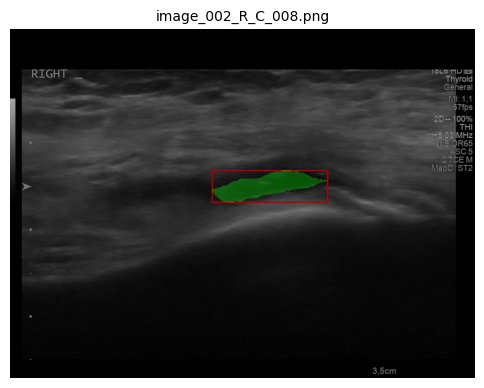

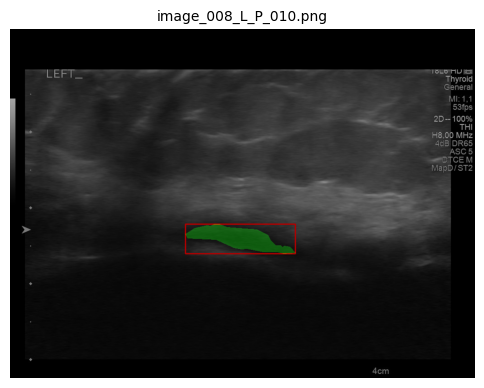

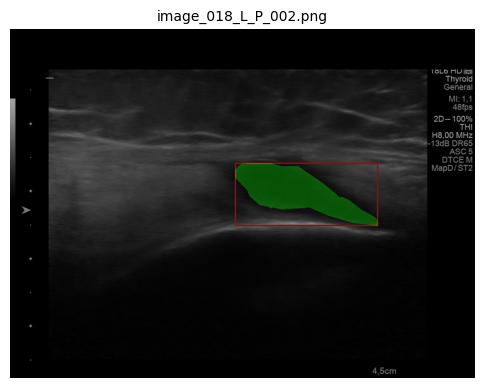

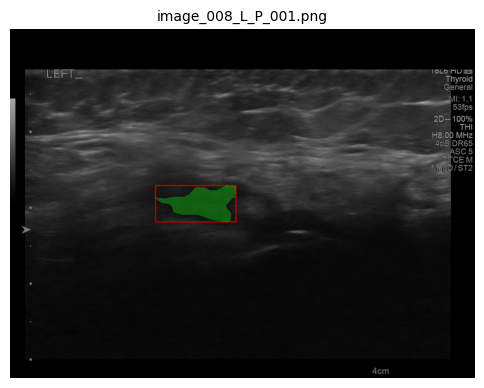

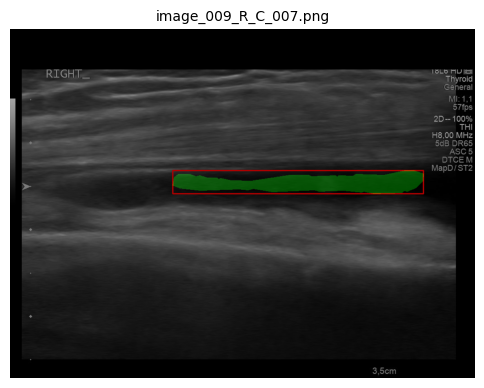

In [6]:
import json
import os
import cv2
import matplotlib.pyplot as plt
from pycocotools import mask as maskUtils
from PIL import Image
import numpy as np
import random
from collections import defaultdict

# Yollar
root_dir_combined = "/content/drive/MyDrive/DIZ_EKLEM/data/trainval_all_images"
json_path_combined = "/content/drive/MyDrive/DIZ_EKLEM/data/trainval_all_coco.json"

# JSON yükleme
with open(json_path_combined) as f:
    coco_data = json.load(f)

# id -> image bilgisi
id_to_filename = {img["id"]: img["file_name"] for img in coco_data["images"]}

# image_id -> annotation listesi
image_to_anns = defaultdict(list)
for ann in coco_data["annotations"]:
    image_to_anns[ann["image_id"]].append(ann)

# Rastgele 5 image_id seç
random_image_ids = random.sample(list(image_to_anns.keys()), 5)

# Görselleri sırayla göster
for image_id in random_image_ids:
    file_name = id_to_filename[image_id]
    img_path = os.path.join(root_dir_combined, file_name)

    image = np.array(Image.open(img_path).convert("RGB"))
    mask_overlay = np.zeros_like(image)

    for ann in image_to_anns[image_id]:
        if isinstance(ann["segmentation"], list):
            for seg in ann["segmentation"]:
                points = np.array(seg).reshape((-1, 2)).astype(np.int32)
                cv2.fillPoly(mask_overlay, [points], color=(0, 255, 0))
        elif isinstance(ann["segmentation"], dict):
            rle = ann["segmentation"]
            m = maskUtils.decode(rle)
            mask_overlay[m == 1] = (0, 255, 0)

        x, y, w, h = map(int, ann["bbox"])
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    overlayed = cv2.addWeighted(image, 0.7, mask_overlay, 0.3, 0)

    # Her resmi tek tek göster
    plt.figure(figsize=(6, 6))
    plt.imshow(overlayed)
    plt.axis("off")
    plt.title(file_name, fontsize=10)
    plt.show()
